# **LOS/NLOS Classifier Model**

## **Project Setup**
### **Import libraries**
Import all basic libraries here. Additional libraries needed later in the notebook can be done at the code cells they are needed for.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

## **Load data**
Load all 7 indoor environment datasets into a single dataframe

In [2]:
dataset_path = "../dataset/"  # Dataset directory

csv_files = [
    f for f in os.listdir(dataset_path) if f.endswith(".csv")
]  # Retrieve all csv files in the dataset folder

print(csv_files)  # print out all the csv file name in the 'dataset' folder

# Load and print out dataset values
dfs = []
for file in csv_files:
    print(f"Reading file: {file}")  # Print the file name being read
    df_temp = pd.read_csv(os.path.join(dataset_path, file))  # Read the CSV file
    # print(df_temp)  # Print the entire data of the current CSV file
    dfs.append(df_temp)  # Append the DataFrame to the list

df = pd.concat(
    dfs, ignore_index=True
)  # combining all datasets (csv) files into one DataFrame
print(df)

['uwb_dataset_part2.csv', 'uwb_dataset_part3.csv', 'uwb_dataset_part1.csv', 'uwb_dataset_part4.csv', 'uwb_dataset_part5.csv', 'uwb_dataset_part7.csv', 'uwb_dataset_part6.csv']
Reading file: uwb_dataset_part2.csv
Reading file: uwb_dataset_part3.csv
Reading file: uwb_dataset_part1.csv
Reading file: uwb_dataset_part4.csv
Reading file: uwb_dataset_part5.csv
Reading file: uwb_dataset_part7.csv
Reading file: uwb_dataset_part6.csv
       NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
0       1.0   6.18   749.0   4889.0  13876.0  10464.0        240.0   9048.0   
1       1.0   4.54   741.0   2474.0   2002.0   1593.0         68.0   6514.0   
2       1.0   4.39   744.0   1934.0   2615.0   4114.0         52.0   2880.0   
3       1.0   1.27   748.0  16031.0  17712.0  10420.0         64.0  12855.0   
4       0.0   1.16   743.0  20070.0  19886.0  15727.0         76.0  11607.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41995   0.0   4.09 

Reading the shape and columns of the dataframe provides information on all the data.

In [3]:
# 'df' variable => combine all dataframe into one
print(
    "Number of rows and Column in dataset:", df.shape
)  # shape of the datasets (the total columns and rolls -> matrix[columns,rows])
print(
    "Number of rows in dataset:", df.columns
)  # total columns/attribute in the all datasets

print(
    "number of records in overall datasets:", len(df)
)  # Print the number of records in the all datasets

Number of rows and Column in dataset: (42000, 1031)
Number of rows in dataset: Index(['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
       'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
       ...
       'CIR1006', 'CIR1007', 'CIR1008', 'CIR1009', 'CIR1010', 'CIR1011',
       'CIR1012', 'CIR1013', 'CIR1014', 'CIR1015'],
      dtype='object', length=1031)
number of records in overall datasets: 42000


## **Data Preparation (Data Cleaning & Data Preprocessing)**
**Data Cleaning for NaN values**

For data cleaning, we counted the total number of missing (NaN) values in the dataframe. If there is existing missing values, the rows are dropped and the new dataframe is returned to df_clean.

In [4]:
# df_clean => to stored datastet that has been cleaned ("clean" => No null value)
MissingValCount = (
    df.isnull().sum()
)  # calculate the missing values in the datasets base on each column
# print(MissingValCount)  # Print the missing values in the datasets for each column
if (
    MissingValCount.sum() > 0
):  # .sum() because to combine all the columns total value into one value
    df_clean = (
        df.dropna()
    )  # drop the missing values in the datasets and store in new variable
    print(f"Total missing values found and removed: {MissingValCount.sum()} rows dropped.")
else:
    df_clean = df.copy()  # Copy the datasets to new variable
    print("No missing values found in datasets")

print("Before cleaning, dataset rows and columns:", df.shape)
print("After cleaning, dataset rows and columns:", df_clean.shape)

print("")

# check if theres any different
if df.shape == df_clean.shape:
    print("The number of rows and columns are the same in both datasets.")
else:
    rows_diff = df.shape[0] - df_clean.shape[0]
    cols_diff = df.shape[1] - df_clean.shape[1]
    print(
        "The number of rows and columns are different between the original and cleaned datasets.",
        f"Rows difference: {rows_diff}, Columns difference: {cols_diff}",
    )

No missing values found in datasets
Before cleaning, dataset rows and columns: (42000, 1031)
After cleaning, dataset rows and columns: (42000, 1031)

The number of rows and columns are the same in both datasets.


### **Data Visualization and Data Cleaning**

**Target Variable: NLOS**

This Graph shows that it's effectively visualizes the proportional distribution, making it easy to compare their equal representation at a glance

Conclusion: The NLOS variable is evenly distributed, with 50% of the data belonging to LOS and 50% to NLOS


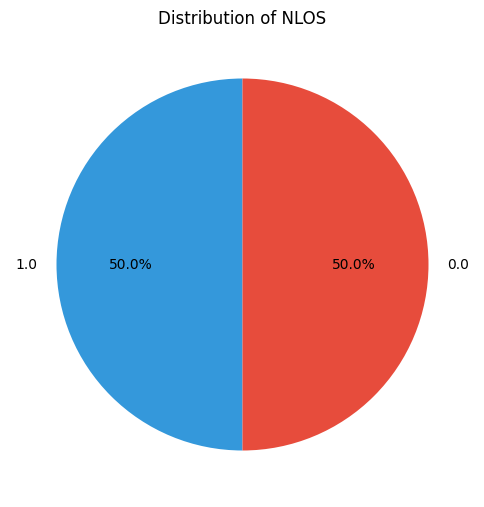

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# count the total in NLOS attribute in the datasets
count_NLOS = df_clean["NLOS"].value_counts()

# visualization to show the distributionfor the 'NLOS' attribute
plt.figure(figsize=(6, 10))
count_NLOS.plot.pie(autopct="%1.1f%%", colors=["#3498db", "#e74c3c"], startangle=90)
plt.title("Distribution of NLOS")
plt.ylabel("")
plt.show()

**Target Variable: FP_IDX**

This Graph compares the distribution of FP_IDX values between LOS and NLOS, Showing any differences in their statistical properties.

Conclusion: The boxplot shows the spread of FP_IDX for both LOS and NLOS. NLOS has an outlier, indicating a potential anomaly.

In [6]:
# Calculate the Range using IQR to remove extreme values
Q1 = df_clean["FP_IDX"].quantile(0.25)
Q3 = df_clean["FP_IDX"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df_clean[
    (df_clean["FP_IDX"] < lower_bound) | (df_clean["FP_IDX"] > upper_bound)
]

# Filter out outliers separately for LOS and NLOS
# For LOS
df_clean_filtered_LOS = df_clean[
    (df_clean["FP_IDX"] >= lower_bound)
    & (df_clean["FP_IDX"] <= upper_bound)
    & (df_clean["NLOS"] == 0.0)
]

# For NLOS
df_clean_filtered_NLOS = df_clean[
    (df_clean["FP_IDX"] >= lower_bound)
    & (df_clean["FP_IDX"] <= upper_bound)
    & (df_clean["NLOS"] == 1.0)
]

# Combine the both cleaned dataset (LOS and NLOS)
df_clean_filtered = pd.concat([df_clean_filtered_LOS, df_clean_filtered_NLOS])

# Remove redundant columns
if "category" in df_clean_filtered.columns and "NLOS" in df_clean_filtered.columns:
    df_clean_filtered = df_clean_filtered.drop(columns=["NLOS"])

# Rename 'Signal_Path' is use to identify whether a signal is in a LOS or NLOS .
df_clean_filtered = (
    df_clean_filtered.rename(columns={"NLOS": "Signal_Path"})
    if "NLOS" in df_clean_filtered.columns
    else df_clean_filtered
)

# Print outliers
print("Outliers for 'FP_IDX':\n", outliers)

Outliers for 'FP_IDX':
        NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
26      1.0   4.54   737.0   2066.0   4232.0   3116.0         84.0   3789.0   
31      1.0   8.88   736.0   1823.0   1750.0   1277.0         76.0   4493.0   
46      1.0   5.86   737.0   3448.0   5723.0   3512.0         84.0    953.0   
49      1.0   7.32   734.0   2304.0   1919.0   1957.0         72.0   9314.0   
62      1.0  12.57   731.0   3438.0   1617.0   1713.0         76.0   1596.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41868   1.0   3.39   722.0    711.0   1391.0    829.0         88.0   2237.0   
41869   1.0   7.09   736.0   1501.0   1581.0    969.0         64.0    297.0   
41910   1.0   7.33   736.0    272.0   1719.0   1823.0         88.0   1561.0   
41969   1.0  13.13   727.0    719.0   1209.0   1395.0         88.0    924.0   
41982   1.0   4.64   733.0   1005.0   2047.0   1514.0         60.0    396.0   

       MAX_NOISE  RXPACC  .

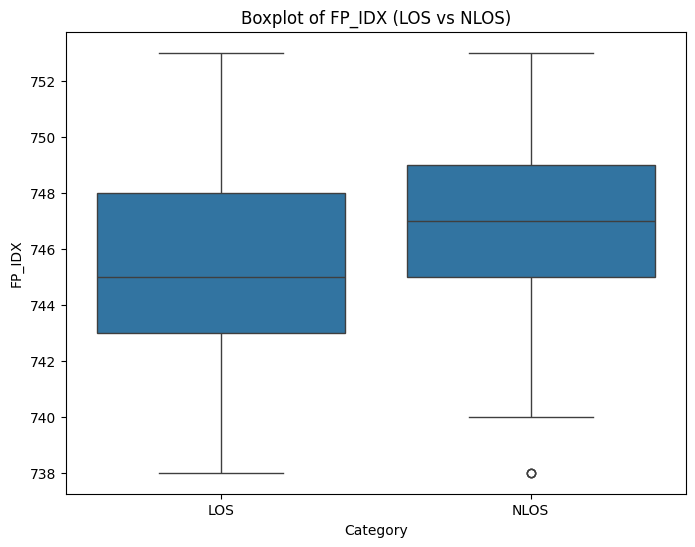

In [7]:
# Filter out outliers based on the calculated bounds using IQR method for both LOS and NLOS
df_clean_filtered = df_clean[
    (df_clean["FP_IDX"] >= lower_bound) & (df_clean["FP_IDX"] <= upper_bound)
].copy()
# Create a new column to indicate the category (LOS or NLOS)
df_clean_filtered.loc[:, "Category"] = df_clean_filtered["NLOS"].apply(
    lambda x: "LOS" if x == 1.0 else "NLOS"
)

# Visualization Graph
plt.figure(figsize=(8, 6))
sns.boxplot(x="Category", y="FP_IDX", data=df_clean_filtered)
plt.title("Boxplot of FP_IDX (LOS vs NLOS)")
plt.show()

**Target Variable: FP_AMP1, FP_AMP2**, **FP_AMP3**

This Graph shows the spread and median of FP_AMP1, FP_AMP2, and FP_AMP3, as their ranges are similar.

Conclusion: FP_AMP1, FP_AMP2, and FP_AMP3 have similar ranges, spread, and median. However, the median and spread for FP_AMP1 are slightly higher than the other two.

**Identifying the range using IQR to remove outliners**

In [8]:
# Calculate the Range using IQR for FP_AMP1
Q1_FP_AMP1 = df_clean["FP_AMP1"].quantile(0.25)
Q3_FP_AMP1 = df_clean["FP_AMP1"].quantile(0.75)
IQR_FP_AMP1 = Q3_FP_AMP1 - Q1_FP_AMP1
lower_bound_FP_AMP1 = Q1_FP_AMP1 - 1.5 * IQR_FP_AMP1
upper_bound_FP_AMP1 = Q3_FP_AMP1 + 1.5 * IQR_FP_AMP1

# Identify outliers
outliers_FP_AMP1 = df_clean[
    (df_clean["FP_AMP1"] < lower_bound_FP_AMP1)
    | (df_clean["FP_AMP1"] > upper_bound_FP_AMP1)
]

# Filter out outliers based on the calculated bounds using IQR method
df_clean_filtered_FP_AMP1 = df_clean[
    (df_clean["FP_AMP1"] >= lower_bound_FP_AMP1)
    & (df_clean["FP_AMP1"] <= upper_bound_FP_AMP1)
]

# Print outliers
print("Outliers for 'FP_AMP1':\n", outliers_FP_AMP1)

Outliers for 'FP_AMP1':
 Empty DataFrame
Columns: [NLOS, RANGE, FP_IDX, FP_AMP1, FP_AMP2, FP_AMP3, STDEV_NOISE, CIR_PWR, MAX_NOISE, RXPACC, CH, FRAME_LEN, PREAM_LEN, BITRATE, PRFR, CIR0, CIR1, CIR2, CIR3, CIR4, CIR5, CIR6, CIR7, CIR8, CIR9, CIR10, CIR11, CIR12, CIR13, CIR14, CIR15, CIR16, CIR17, CIR18, CIR19, CIR20, CIR21, CIR22, CIR23, CIR24, CIR25, CIR26, CIR27, CIR28, CIR29, CIR30, CIR31, CIR32, CIR33, CIR34, CIR35, CIR36, CIR37, CIR38, CIR39, CIR40, CIR41, CIR42, CIR43, CIR44, CIR45, CIR46, CIR47, CIR48, CIR49, CIR50, CIR51, CIR52, CIR53, CIR54, CIR55, CIR56, CIR57, CIR58, CIR59, CIR60, CIR61, CIR62, CIR63, CIR64, CIR65, CIR66, CIR67, CIR68, CIR69, CIR70, CIR71, CIR72, CIR73, CIR74, CIR75, CIR76, CIR77, CIR78, CIR79, CIR80, CIR81, CIR82, CIR83, CIR84, ...]
Index: []

[0 rows x 1031 columns]


In [9]:
# Calculate the Range using IQR for FP_AMP2
Q1_FP_AMP2 = df_clean["FP_AMP2"].quantile(0.25)
Q3_FP_AMP2 = df_clean["FP_AMP2"].quantile(0.75)
IQR_FP_AMP2 = Q3_FP_AMP2 - Q1_FP_AMP2
lower_bound_FP_AMP2 = Q1_FP_AMP2 - 1.5 * IQR_FP_AMP2
upper_bound_FP_AMP2 = Q1_FP_AMP2 + 1.5 * IQR_FP_AMP2

# Identify outliers
outliers_FP_AMP2 = df_clean[
    (df_clean["FP_AMP2"] < lower_bound_FP_AMP2)
    | (df_clean["FP_AMP2"] > upper_bound_FP_AMP2)
]

# Filter out outliers based on the calculated bounds using IQR method
df_clean_filtered_FP_AMP2 = df_clean[
    (df_clean["FP_AMP2"] >= lower_bound_FP_AMP2)
    & (df_clean["FP_AMP2"] <= upper_bound_FP_AMP2)
]

# Print outliers
print("Outliers for 'FP_AMP2':\n", outliers_FP_AMP2)

Outliers for 'FP_AMP2':
 Empty DataFrame
Columns: [NLOS, RANGE, FP_IDX, FP_AMP1, FP_AMP2, FP_AMP3, STDEV_NOISE, CIR_PWR, MAX_NOISE, RXPACC, CH, FRAME_LEN, PREAM_LEN, BITRATE, PRFR, CIR0, CIR1, CIR2, CIR3, CIR4, CIR5, CIR6, CIR7, CIR8, CIR9, CIR10, CIR11, CIR12, CIR13, CIR14, CIR15, CIR16, CIR17, CIR18, CIR19, CIR20, CIR21, CIR22, CIR23, CIR24, CIR25, CIR26, CIR27, CIR28, CIR29, CIR30, CIR31, CIR32, CIR33, CIR34, CIR35, CIR36, CIR37, CIR38, CIR39, CIR40, CIR41, CIR42, CIR43, CIR44, CIR45, CIR46, CIR47, CIR48, CIR49, CIR50, CIR51, CIR52, CIR53, CIR54, CIR55, CIR56, CIR57, CIR58, CIR59, CIR60, CIR61, CIR62, CIR63, CIR64, CIR65, CIR66, CIR67, CIR68, CIR69, CIR70, CIR71, CIR72, CIR73, CIR74, CIR75, CIR76, CIR77, CIR78, CIR79, CIR80, CIR81, CIR82, CIR83, CIR84, ...]
Index: []

[0 rows x 1031 columns]


In [10]:
# Calculate the Range using IQR for FP_AMP3
Q1_FP_AMP3 = df_clean["FP_AMP3"].quantile(0.25)
Q3_FP_AMP3 = df_clean["FP_AMP3"].quantile(0.75)
IQR_FP_AMP3 = Q3_FP_AMP3 - Q1_FP_AMP3
lower_bound_FP_AMP3 = Q1_FP_AMP3 - 1.5 * IQR_FP_AMP3
upper_bound_FP_AMP3 = Q1_FP_AMP3 + 1.5 * IQR_FP_AMP3

# Identify outliers
outliers_FP_AMP3 = df_clean[
    (df_clean["FP_AMP3"] < lower_bound_FP_AMP3)
    | (df_clean["FP_AMP3"] > upper_bound_FP_AMP3)
]

# Filter out outliers based on the calculated bounds using IQR method
df_clean_filtered_FP_AMP3 = df_clean[
    (df_clean["FP_AMP3"] >= lower_bound_FP_AMP3)
    & (df_clean["FP_AMP3"] <= upper_bound_FP_AMP3)
]

# Print outliers
print("Outliers for 'FP_IDX':\n", outliers_FP_AMP3)

Outliers for 'FP_IDX':
        NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
104     0.0   5.08   745.0   2922.0  15891.0  19129.0         80.0   9962.0   
123     0.0   1.40   750.0  16026.0  20343.0  19026.0         52.0  12543.0   
145     0.0   5.69   746.0   4278.0  17974.0  20245.0         48.0   9526.0   
185     0.0   1.98   746.0  12539.0  20207.0  19131.0         52.0  15467.0   
365     1.0   6.91   746.0   2318.0  19454.0  20296.0         60.0  23903.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41757   1.0   0.54   751.0   7203.0  19603.0  19507.0        160.0  11759.0   
41829   0.0   4.74   748.0   9000.0  15539.0  19426.0         68.0  10231.0   
41843   0.0   3.47   744.0   7574.0  19104.0  20218.0         52.0  11691.0   
41904   0.0   2.05   749.0   7766.0  18756.0  19044.0         60.0   9430.0   
41953   0.0   0.98   745.0  12354.0  11519.0  19650.0         48.0  15739.0   

       MAX_NOISE  RXPACC  .

This Graph shows thatUsed to show the spread and median of FP_AMP1, FP_AMP2, and FP_AMP3, as their ranges are similar.
Conclusion: FP_AMP1, FP_AMP2, and FP_AMP3 have similar ranges, spread, and median. However, the median and spread for FP_AMP1 are slightly higher than the other two.


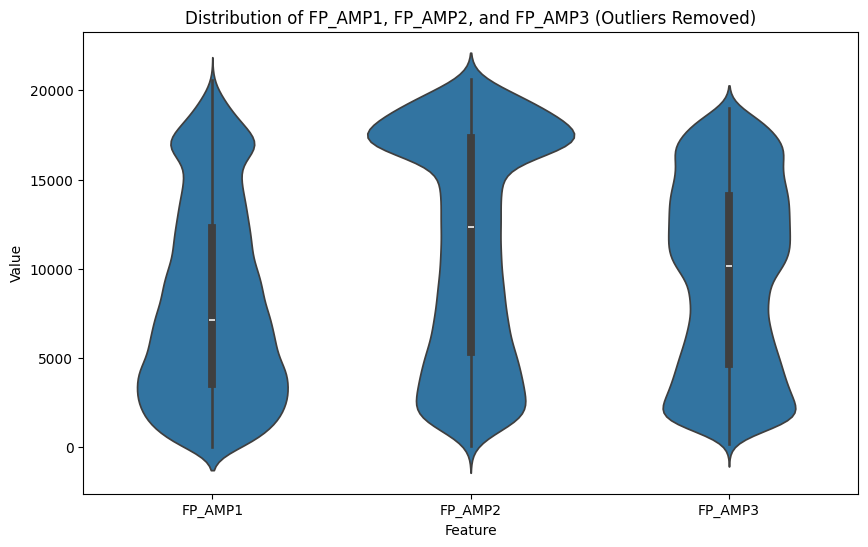

In [11]:
# Combining multiplte dataframe in to one DataFrame
df_filtered = pd.DataFrame(
    {
        "FP_AMP1": df_clean_filtered_FP_AMP1["FP_AMP1"],
        "FP_AMP2": df_clean_filtered_FP_AMP2["FP_AMP2"],
        "FP_AMP3": df_clean_filtered_FP_AMP3["FP_AMP3"],
    }
)

# Reshape the data for the violin plot
df_filtered_melted = df_filtered.melt(var_name="Feature", value_name="Value")
print("This Graph shows thatUsed to show the spread and median of FP_AMP1, FP_AMP2, and FP_AMP3, as their ranges are similar.")
print("Conclusion: FP_AMP1, FP_AMP2, and FP_AMP3 have similar ranges, spread, and median. However, the median and spread for FP_AMP1 are slightly higher than the other two.")


# Create the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x="Feature", y="Value", data=df_filtered_melted)

plt.title("Distribution of FP_AMP1, FP_AMP2, and FP_AMP3 (Outliers Removed)")
plt.show()

**Target Variable: STDEV_NOISE**

This Graph shows the full data distribution for CIR_PWR for LOS and NLOS.

Conclusion: It shows that 0.0 has a lower STDEV_NOISE value compared to 1.0, indicating that noise is more consistent in LOS than in NLOS.

This Graph shows thatIt shows the spread of values for STDEV_NOISE for 0.0 and 1.0.
Conclusion: It shows that 0.0 has a lower STDEV_NOISE value compared to 1.0, indicating that noise is more consistent in LOS than in NLOS.


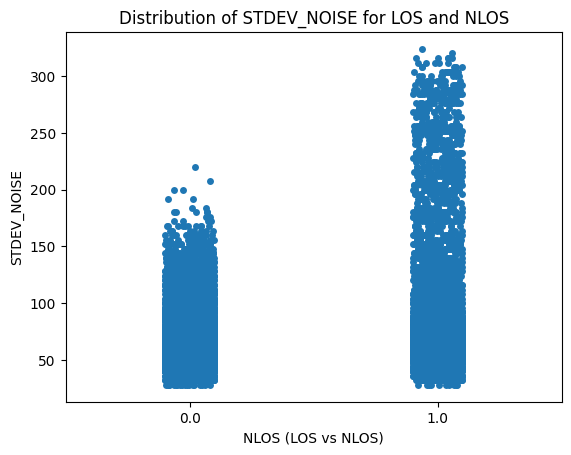

In [12]:
print("This Graph shows thatIt shows the spread of values for STDEV_NOISE for 0.0 and 1.0.")
print("Conclusion: It shows that 0.0 has a lower STDEV_NOISE value compared to 1.0, indicating that noise is more consistent in LOS than in NLOS.")
sns.stripplot(data=df_clean, x="NLOS", y="STDEV_NOISE", jitter=True)
plt.title("Distribution of STDEV_NOISE for LOS and NLOS")
plt.xlabel("NLOS (LOS vs NLOS)")
plt.ylabel("STDEV_NOISE")
plt.show()

**Target Variable: CIR_PWR**

This Graph shows the spread of values for STDEV_NOISE for 0.0 and 1.0.

Conclusion: It shows the XLOS and NLOS status have similar distributions for STDEV_NOISE, but NLOS (1.0) has a wider spread of values.

In [13]:
# Calculate the Range using IQR for CIR_PWR
Q1_CIR_PWR = df_clean["CIR_PWR"].quantile(0.25)
Q3_CIR_PWR = df_clean["CIR_PWR"].quantile(0.75)
IQR_CIR_PWR = Q3_CIR_PWR - Q1_CIR_PWR
lower_bound_CIR_PWR = Q1_CIR_PWR - 1.5 * IQR_CIR_PWR
upper_bound_CIR_PWR = Q3_CIR_PWR + 1.5 * IQR_CIR_PWR

# Identify outliers
outliers_CIR_PWR = df_clean[
    (df_clean["CIR_PWR"] < lower_bound_CIR_PWR)
    | (df_clean["CIR_PWR"] > upper_bound_CIR_PWR)
]

# Filter out outliers based on the calculated bounds using IQR method
df_clean_filtered_CIR_PWR = df_clean[
    (df_clean["CIR_PWR"] >= lower_bound_CIR_PWR)
    & (df_clean["CIR_PWR"] <= upper_bound_CIR_PWR)
]

# Print outliers
print("Outliers for 'CIR_PWR':\n", outliers_CIR_PWR)

Outliers for 'CIR_PWR':
        NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
34      1.0   6.35   746.0  11146.0  10502.0   6624.0         60.0  21115.0   
56      0.0   2.12   747.0  13091.0  16349.0  11204.0        120.0  29570.0   
67      1.0   6.31   750.0  13805.0  19543.0  11380.0         64.0  31759.0   
71      1.0   6.68   745.0  13068.0   9016.0   5174.0         68.0  23124.0   
75      0.0   5.96   748.0  12532.0   8788.0  15810.0        128.0  25006.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41748   1.0   7.64   744.0    248.0  14006.0  12489.0         64.0  22825.0   
41834   0.0   5.09   750.0   8443.0  16866.0  11160.0         68.0  21287.0   
41871   0.0   3.07   746.0   5715.0  10261.0  12889.0         84.0  29942.0   
41922   0.0   1.67   746.0  10780.0  18043.0  14167.0        136.0  26737.0   
41974   1.0   7.59   747.0    108.0  17802.0  17768.0         52.0  24454.0   

       MAX_NOISE  RXPACC  

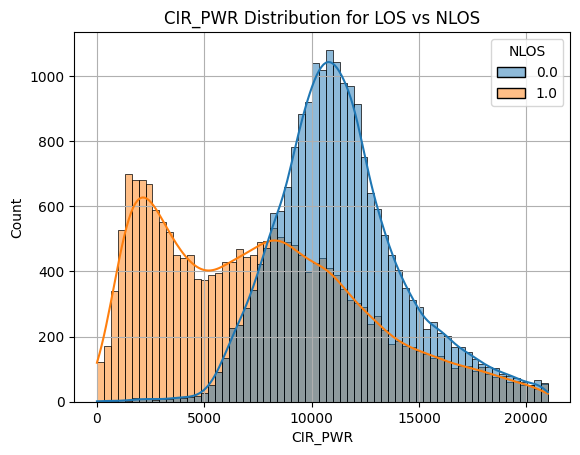

In [14]:
sns.histplot(data=df_clean_filtered_CIR_PWR, x="CIR_PWR", hue="NLOS", kde=True)
plt.title("CIR_PWR Distribution for LOS vs NLOS")
plt.xlabel("CIR_PWR")
plt.ylabel("Count")
plt.grid(True)
plt.show()

**Target Variable: MAX_NOISE**

This Graph shows the distribution of the standard deviation of noise (STDEV_NOISE) for LOS and NLOS categories to observe noise variation.

Conclusion: The plot highlights how noise standard deviation differs between LOS and NLOS, indicating potential implications for data reliability.

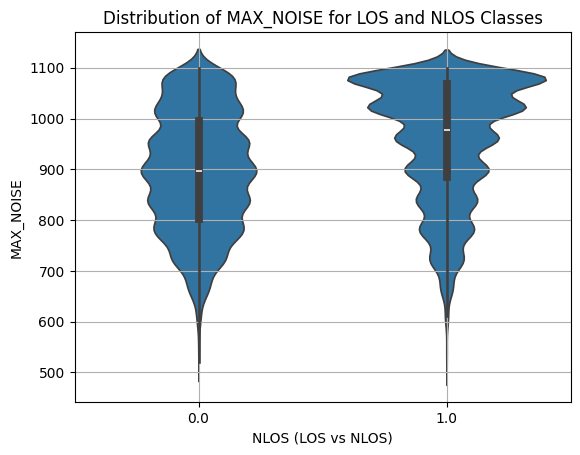

In [15]:
df_clean_filtered = df_clean[
    (df_clean["MAX_NOISE"] >= 500) & (df_clean["MAX_NOISE"] < 1100)
]

sns.violinplot(data=df_clean_filtered, x="NLOS", y="MAX_NOISE")
plt.title("Distribution of MAX_NOISE for LOS and NLOS Classes")
plt.xlabel("NLOS (LOS vs NLOS)")
plt.ylabel("MAX_NOISE")
plt.grid(True)
plt.show()

**Target Variable: RXPACC**

This Graph shows that???

Conclusion: ???

In [16]:
# Calculate the Range using IQR for FP_AMP1
Q1_RXPACC = df_clean["RXPACC"].quantile(0.25)
Q3_RXPACC = df_clean["RXPACC"].quantile(0.75)
IQR_RXPACC = Q3_RXPACC - Q1_RXPACC
lower_bound_RXPACC = Q1_RXPACC - 1.5 * IQR_RXPACC
upper_bound_RXPACC = Q3_RXPACC + 1.5 * IQR_RXPACC

# Identify outliers
outliers_RXPACC = df_clean[
    (df_clean["FP_AMP1"] < lower_bound_RXPACC)
    | (df_clean["FP_AMP1"] > upper_bound_RXPACC)
]

# Filter out outliers based on the calculated bounds using IQR method
df_clean_filtered_RXPACC = df_clean[
    (df_clean["FP_AMP1"] >= lower_bound_RXPACC)
    & (df_clean["FP_AMP1"] <= upper_bound_RXPACC)
]

# Print outliers
print("Outliers for 'RXPACC':\n", outliers_RXPACC)

# Filter the data based on RXPACC values
df_clean_filtered_RXPACC = df_clean[
    (df_clean["RXPACC"] >= 500) & (df_clean["RXPACC"] < 1100)
]

Outliers for 'RXPACC':
        NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
0       1.0   6.18   749.0   4889.0  13876.0  10464.0        240.0   9048.0   
1       1.0   4.54   741.0   2474.0   2002.0   1593.0         68.0   6514.0   
3       1.0   1.27   748.0  16031.0  17712.0  10420.0         64.0  12855.0   
4       0.0   1.16   743.0  20070.0  19886.0  15727.0         76.0  11607.0   
5       1.0   5.04   743.0   6490.0  12580.0   9741.0         92.0   3870.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41994   1.0   5.16   742.0   3132.0   3137.0   1868.0         76.0   3573.0   
41996   0.0   2.18   744.0  14870.0  13482.0   8864.0         44.0  12604.0   
41997   0.0   1.25   748.0  18329.0  17722.0  10731.0         60.0  10192.0   
41998   0.0   3.17   747.0   3654.0  18470.0  17737.0         64.0  12018.0   
41999   1.0   7.24   743.0  15428.0  16758.0  10250.0         60.0  17738.0   

       MAX_NOISE  RXPACC  .

<Figure size 1400x800 with 0 Axes>

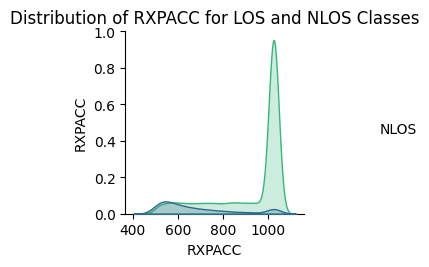

In [17]:
df_plot = df_clean_filtered_RXPACC[["RXPACC", "NLOS"]]

# Increase the figure size by adjusting figsize
plt.figure(figsize=(14, 8)) 
sns.pairplot(df_plot, hue="NLOS", palette="viridis", plot_kws={"alpha": 0.7})
plt.title("Distribution of RXPACC for LOS and NLOS Classes")
plt.grid(True)
plt.show()


       RANGE  STDEV_NOISE   CH  FRAME_LEN  PREAM_LEN  BITRATE  PRFR
0       6.18        240.0  2.0       39.0     1024.0    110.0  64.0
1       4.54         68.0  2.0       39.0     1024.0    110.0  64.0
2       4.39         52.0  2.0       27.0     1024.0    110.0  64.0
3       1.27         64.0  2.0       39.0     1024.0    110.0  64.0
4       1.16         76.0  2.0       27.0     1024.0    110.0  64.0
...      ...          ...  ...        ...        ...      ...   ...
41995   4.09         88.0  2.0       27.0     1024.0    110.0  64.0
41996   2.18         44.0  2.0       39.0     1024.0    110.0  64.0
41997   1.25         60.0  2.0       39.0     1024.0    110.0  64.0
41998   3.17         64.0  2.0       39.0     1024.0    110.0  64.0
41999   7.24         60.0  2.0       39.0     1024.0    110.0  64.0

[42000 rows x 7 columns]


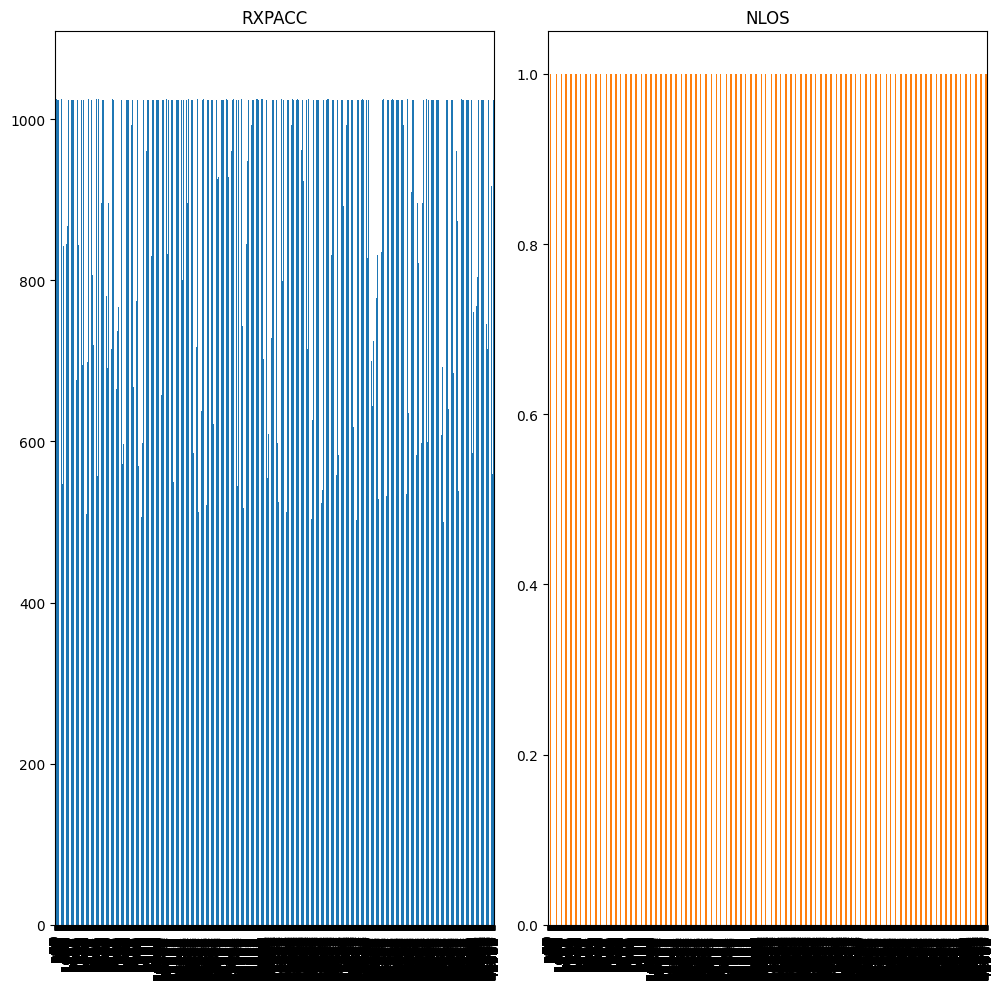

In [18]:
# List of specific columns to exclude
columns_to_exclude = [
    "NLOS",
    "FP_IDX",
    "FP_AMP1",
    "FP_AMP2",
    "FP_AMP3",
    "CIR_PWR",
    "MAX_NOISE",
    "RXPACC",
]

# Drop columns that start with "CIR" using .filter() and a regex pattern
columns_to_exclude += [col for col in df_clean.columns if col.startswith("CIR")]

df_clean_copy = df_clean.drop(columns=columns_to_exclude)

print(df_clean_copy)  # Print the updated dataframe

# Set figure size
df_plot.plot(kind="bar", subplots=True, figsize=(15, 10), layout=(-1, 3), legend=False)

# Adjust layout and show plot
plt.tight_layout()
plt.show()

For **FRAME_LEN**

#conclusion

#visualization usage purpose

FRAME_LEN
39.0    23806
27.0    18193
29.0        1
Name: count, dtype: int64


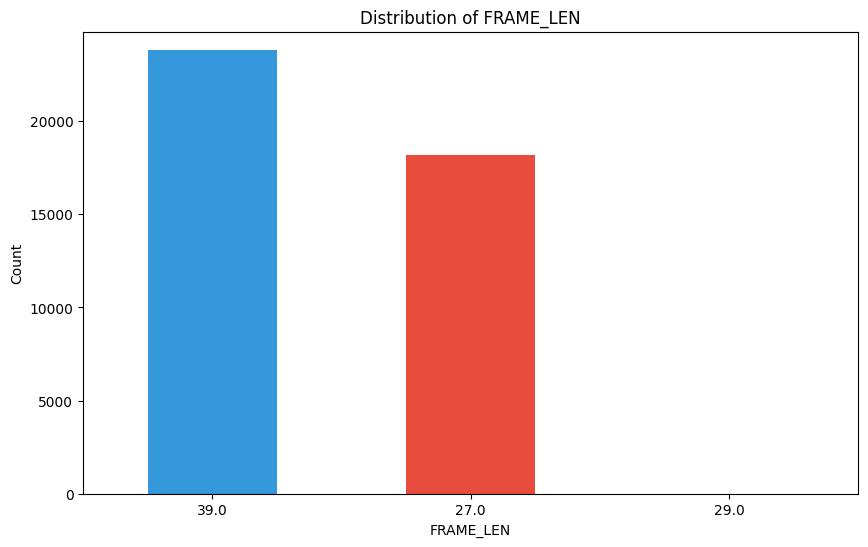

In [19]:
# Count occurrences of 'FRAME_LEN' values
count_framelen = df_clean["FRAME_LEN"].value_counts()
print(count_framelen)

# Plot the distribution
plt.figure(figsize=(10, 6))
count_framelen.plot.bar(
    color=["#3498db", "#e74c3c", "#f39c12"]
)  # Optional color customization
plt.title("Distribution of FRAME_LEN")
plt.ylabel("Count")
plt.xlabel("FRAME_LEN")
plt.xticks(rotation=0)

# Adjust y-axis to ensure all values are visible
plt.yscale(
    "linear"
)  # Ensures that the scale is linear and smaller values show up properly
plt.ylim(0, count_framelen.max() + 1000)  # Extend the y-axis a bit to give space

plt.show()

For **PREAM_LEN**

#conclusion

#visualization usage purpose

PREAM_LEN
1024.0    40443
1536.0     1557
Name: count, dtype: int64


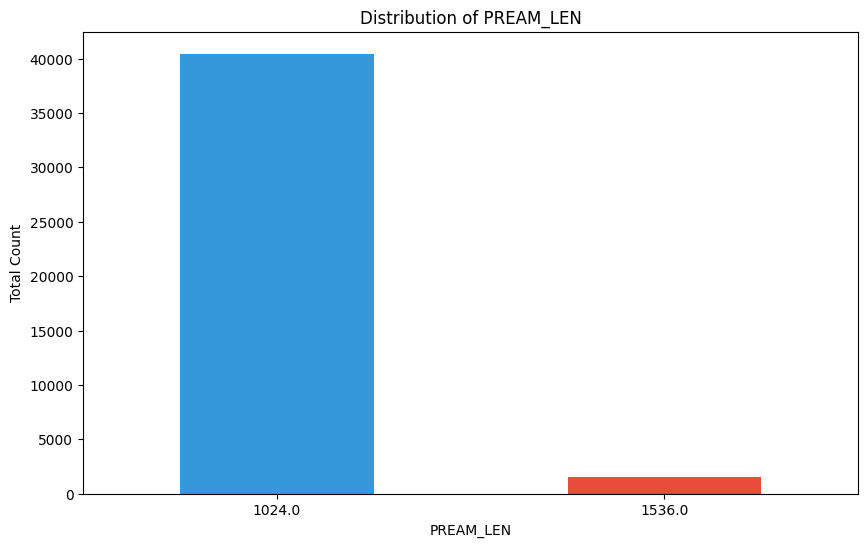

In [20]:
# Count occurrences of 'FRAME_LEN' values
count_PREAM_LEN = df_clean["PREAM_LEN"].value_counts()
print(count_PREAM_LEN)

# Plot the distribution
plt.figure(figsize=(10, 6))
count_PREAM_LEN.plot.bar(color=["#3498db", "#e74c3c"])
plt.title("Distribution of PREAM_LEN")
plt.ylabel("Total Count")
plt.xticks(rotation=0)
plt.show()

For **PRFR** and **BITRATE** (Has an fixed value)

#conclusion

#visualization usage purpose

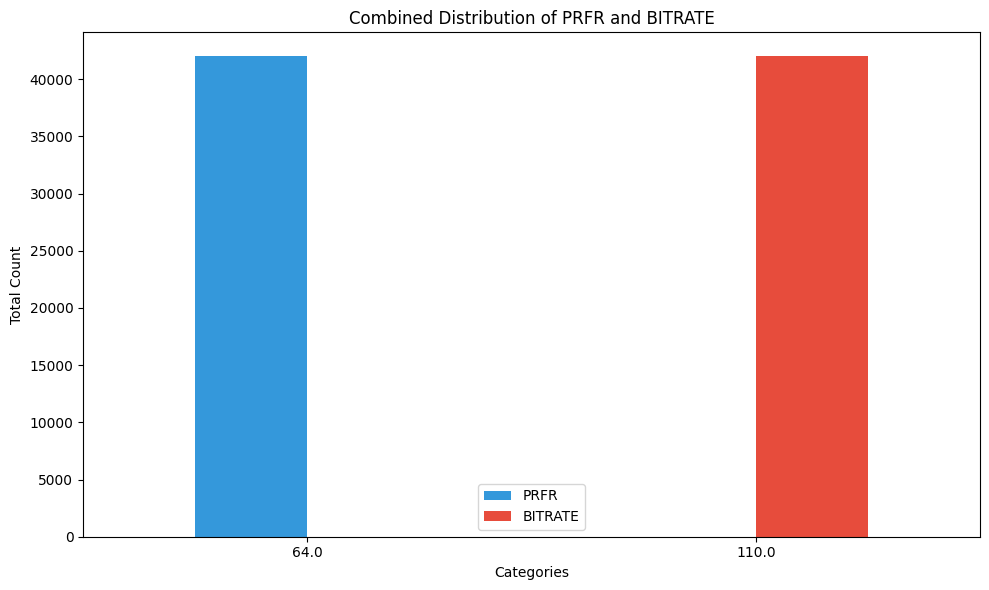

In [21]:
# Count occurrences of 'PRFR' values
count_PRFR = df_clean["PRFR"].value_counts()

# Count occurrences of 'BITRATE' values
count_BITRATE = df_clean["BITRATE"].value_counts()

# Combine the counts into a DataFrame
combined_df = pd.DataFrame(
    {"PRFR": count_PRFR, "BITRATE": count_BITRATE, "BITRATE": count_BITRATE}
).fillna(0)
# Plot the combined distribution (side-by-side bars)
combined_df.plot(kind="bar", figsize=(10, 6), color=["#3498db", "#e74c3c"])

# Set plot labels and title
plt.title("Combined Distribution of PRFR and BITRATE")
plt.ylabel("Total Count")
plt.xlabel("Categories")
plt.xticks(rotation=0)  # Keep x-axis labels clear

plt.tight_layout()
plt.show()

For **RANGE**

#conclusion

#visualization usage purpose

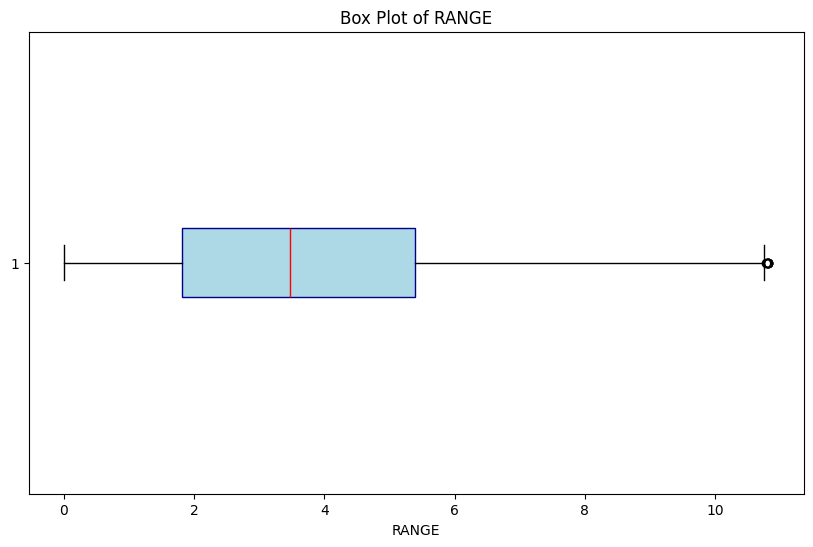

In [22]:
# Calculate the Range using IQR for RANGE
Q1_RANGE = df_clean["RANGE"].quantile(0.25)
Q3_RANGE = df_clean["RANGE"].quantile(0.75)
IQR_RANGE = Q3_RANGE - Q1_RANGE
lower_bound_RANGE = Q1_RANGE - 1.5 * IQR_RANGE
upper_bound_RANGE = Q3_RANGE + 1.5 * IQR_RANGE

# Identify outliers
outliers_RANGE = df_clean[
    (df_clean["RANGE"] < lower_bound_RANGE) | (df_clean["RANGE"] > upper_bound_RANGE)
]

# Filter out outliers based on the calculated bounds using IQR method
df_clean_filtered_RANGE = df_clean[
    (df_clean["RANGE"] >= lower_bound_RANGE) & (df_clean["RANGE"] <= upper_bound_RANGE)
]

# Box plot to show distribution of RANGE values
plt.figure(figsize=(10, 6))
plt.boxplot(
    df_clean_filtered_RANGE["RANGE"],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="darkblue"),
    medianprops=dict(color="red"),
)
plt.title("Box Plot of RANGE")
plt.xlabel("RANGE")
plt.show()

### **Data Visualization and Data Preprocessing**

#### **Feature Importance**

**Correlation Matrix**

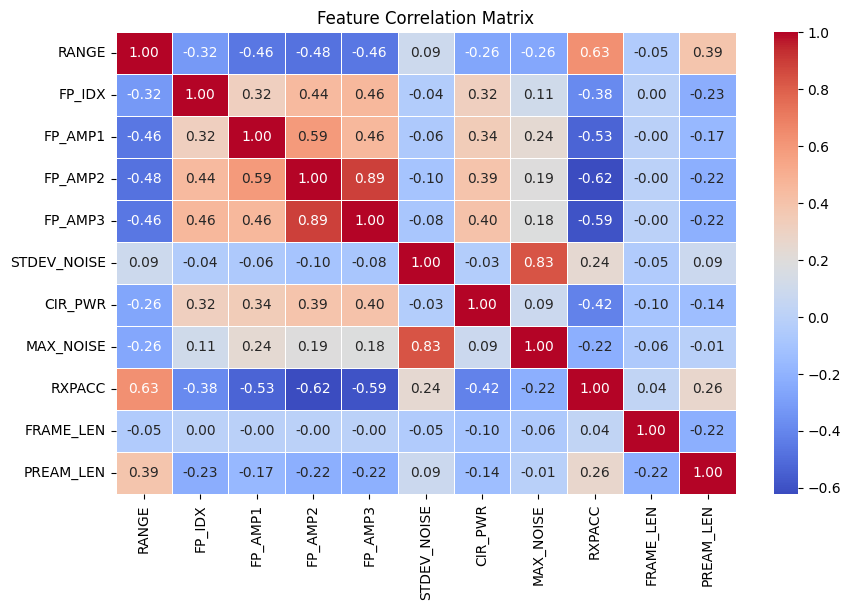

In [23]:
features = [
    "RANGE",
    "FP_IDX",
    "FP_AMP1",
    "FP_AMP2",
    "FP_AMP3",
    "STDEV_NOISE",
    "CIR_PWR",
    "MAX_NOISE",
    "RXPACC",
    "FRAME_LEN",
    "PREAM_LEN",
]

# Compute correlation matrix
correlation_matrix = df_clean[features].corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

**Mutual Information**


Mutual Information Scores (in descending order):
RXPACC         0.381717
MAX_NOISE      0.218647
CIR_PWR        0.180663
FP_AMP2        0.152167
FP_AMP1        0.150587
FP_AMP3        0.138812
STDEV_NOISE    0.113134
FP_IDX         0.089737
PREAM_LEN      0.078770
FRAME_LEN      0.010017
dtype: float64


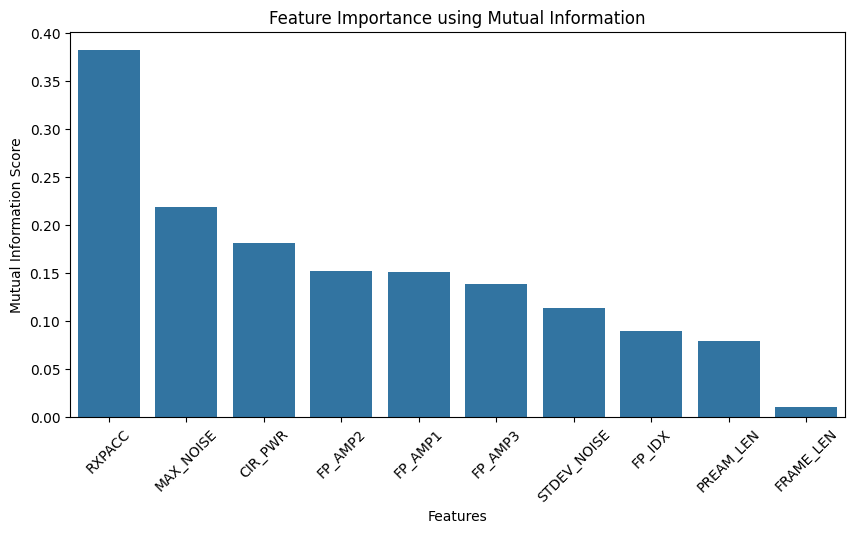

In [24]:
# mutual information (to check the relationship between the features)
from sklearn.feature_selection import mutual_info_regression

# Features
features = [
    "FP_IDX",
    "FP_AMP1",
    "FP_AMP2",
    "FP_AMP3",
    "STDEV_NOISE",
    "CIR_PWR",
    "MAX_NOISE",
    "RXPACC",
    "FRAME_LEN",
    "PREAM_LEN",
]

# Define X as features set
X = df_clean[features]

# Define target variable
y = df_clean["RANGE"]

# Compute mutual information scores
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, index=features)

# Sort the scores in descending order and print
mi_scores = mi_scores.sort_values(ascending=False)
print("Mutual Information Scores (in descending order):")
print(mi_scores)

# Plot the scores for better visualization
plt.figure(figsize=(10, 5))
sns.barplot(x=mi_scores.index, y=mi_scores.values)
plt.xlabel("Features")
plt.ylabel("Mutual Information Score")
plt.title("Feature Importance using Mutual Information")
plt.xticks(rotation=45)
plt.show()

#### **Normalization**

After normalization, we can see that the values well-balanced for classification, successfully normalized but some features exhibit skewness.



In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Split dataset into training and test sets
X = df_clean.drop(columns=["NLOS"])
y = df_clean["NLOS"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize features using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Use transform(), not fit_transform()

# Convert back to DataFrame
X_train = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns)

**Principal Component Analysis (PCA)**

PCA on CIR Features

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

cir_features = [f"CIR{i}" for i in range(1016)]
X_cir = df_clean[cir_features]

# Standardization before PCA
scaler = StandardScaler()
X_cir_scaled = scaler.fit_transform(X_cir)

# PCA Analysis
pca = PCA(n_components=0.95)  # Retain 95% variance
X_cir_pca = pca.fit_transform(X_cir_scaled)
reduced_features = X_cir_pca.shape[1]

print(
    f"New shape after PCA: {X_cir_pca.shape} (Reduced to {reduced_features} components)"
)

# Convert PCA-transformed data into a DataFrame
pca_feature_names = [f"PCA_{i}" for i in range(reduced_features)]
df_pca = pd.DataFrame(X_cir_pca, columns=pca_feature_names)

# Remove original CIR features and replace with PCA-transformed data
df_clean = df_clean.drop(columns=cir_features).reset_index(drop=True)
df_clean = pd.concat([df_clean, df_pca], axis=1)

New shape after PCA: (42000, 862) (Reduced to 862 components)


PCA Explained Variance

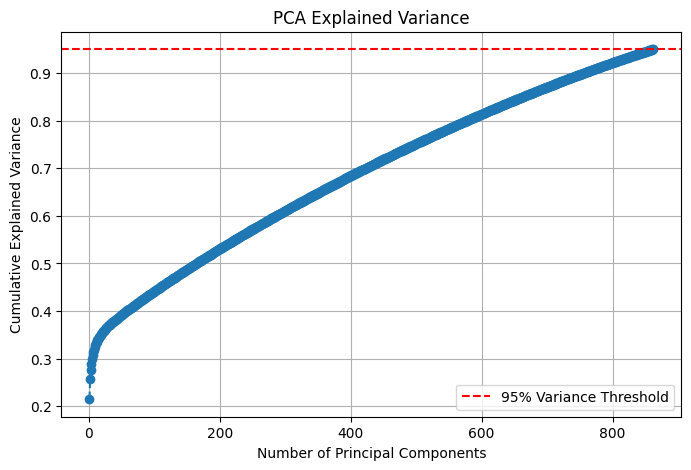

In [27]:
# === Step 5: PCA Explained Variance === #
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot Explained Variance
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
    linestyle="--",
)
plt.axhline(y=0.95, color="r", linestyle="--", label="95% Variance Threshold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

### **Data Minning**

#### **Data Splitting**

Start by splitting the dataset into training and testing sets.

In [28]:
from sklearn.model_selection import train_test_split

# Remove CIR columns => PCA already reduce them
df_clean = df_clean.loc[:, ~df_clean.columns.str.match(r"^CIR\d+$")]

# Remove low-importance features => no need for them
low_mi_features = ["FRAME_LEN", "PREAM_LEN"]
df_clean = df_clean.drop(columns=low_mi_features, errors="ignore")

# Combine FP_AMP columns => into one average
df_clean["FP_AMP_AVG"] = df_clean[["FP_AMP1", "FP_AMP2", "FP_AMP3"]].mean(axis=1)
df_clean = df_clean.drop(columns=["FP_AMP1", "FP_AMP2", "FP_AMP3"], errors="ignore")

# Define features and target
X = df_clean.drop(columns=["NLOS"])
y = df_clean["NLOS"]

# Split data into train and test 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Print shape of the datasets (Size of the datasets)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (33600, 872)
Shape of X_test: (8400, 872)
Shape of y_train: (33600,)
Shape of y_test: (8400,)


#### **Model Training and Tuning**

Train a Random Forest Classifier and tune it using GridSearchCV.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np

rf_model = RandomForestClassifier(random_state=42)

# hyperparameter grid for tuning
param_grid = {
    "n_estimators": [100, 200, 300],  # Number of trees in the forest
    "max_depth": [10, 20, 30],
    "min_samples_split": [2, 5, 10],  # split a node
    "min_samples_leaf": [1, 2, 4],  # each leaf node
}

# For hyperparameter tuning with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=rf_model, param_grid=param_grid, cv=5, scoring="accuracy", verbose=1
)

# Calculate total number of combinations to be tested
total_combinations = (
    len(param_grid["n_estimators"])
    * len(param_grid["max_depth"])
    * len(param_grid["min_samples_split"])
    * len(param_grid["min_samples_leaf"])
)
print(f"Total combinations: {total_combinations}")

# Run the grid search and tune hyperparameters => showing updates (To ensure its running this line/section)
grid_search.fit(X_train, y_train)

# Best model => After hyperparameter tuning
best_rf_model = grid_search.best_estimator_

print("Best Hyperparameters:", grid_search.best_params_)

Total combinations: 81
Fitting 5 folds for each of 81 candidates, totalling 405 fits


#### **Model Evaluation (Confusion Matrix, Accuracy, and AUC)**

After training, let's evaluate the model using different metrics like accuracy, confusion matrix, and AUC score.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = best_rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# confusion matrix to evaluate performance
conf_matrix = confusion_matrix(y_test, y_pred)
# plot graph
plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",  # as integers
    cmap="Blues",
    xticklabels=["NLOS", "LOS"],
    yticklabels=["NLOS", "LOS"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Calculate ROC AUC score =>  tells us how well the model distinguishes between classes
roc_auc = roc_auc_score(y_test, best_rf_model.predict_proba(X_test)[:, 1])
print(f"ROC AUC: {roc_auc:.4f}")

# Generate ROC curve => Receiver Operating Characteristic curve
fpr, tpr, thresholds = roc_curve(y_test, best_rf_model.predict_proba(X_test)[:, 1])

# plot graph
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="b", label="ROC Curve")  # Plot ROC curve
plt.plot([0, 1], [0, 1], color="r", linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

#### **Feature Importance**

Random Forest provides feature importance out of the box, so you can easily plot which features are contributing the most to the model's decisions.

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

# Get feature importance => from the trained RandomForest model previous code
feature_importances = best_rf_model.feature_importances_

# store feature names and their corresponding importance values
feature_importance_df = pd.DataFrame(
    {"Feature": X.columns, "Importance": feature_importances}
)

# Sort the features
feature_importance_df = feature_importance_df.sort_values(
    by="Importance", ascending=False  # from high to low
)

# # Plot graph => Top 20 features by importance
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance", y="Feature", data=feature_importance_df.head(20), palette="viridis"
)
plt.title("Top 20 Features by Importance")
plt.show()

# Evaluate the model's performance on the test set
print(classification_report(y_test, y_pred))

#### **Model Evaluation on Test Data**

Now let's evaluate the model on the test dataset to see how it performs on unseen data.

In [ ]:
from sklearn.metrics import (
    classification_report,
)  # For precision, recall, f1-score, and support

#  model predictions on the test set
y_test_pred = best_rf_model.predict(X_test)

print(classification_report(y_test, y_test_pred))

# AUC ROC curve => Receiver Operating Characteristic curve
fpr, tpr, thresholds = roc_curve(y_test, best_rf_model.predict_proba(X_test)[:, 1])

# Plot graph
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="b", label="ROC Curve")
plt.plot([0, 1], [0, 1], color="r", linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test Set ROC Curve")
plt.legend(loc="lower right")
plt.show()

#### **Final Model Deployment**

Once you have selected the best model and evaluated its performance, you can export it for deployment.

In [ ]:
import joblib

# Save the Random Forest model
joblib.dump(best_rf_model, "best_rf_model.pkl")

# Save the scaler for future transformations
joblib.dump(scaler, "scaler.pkl")

# Save the PCA model
joblib.dump(pca, "pca_model.pkl")
print(
    "Model and preprocessing steps saved as best_rf_model.pkl, scaler.pkl, and pca_model.pkl"
)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

# Predict on the test set using the best model
y_pred = best_rf_model.predict(X_test)

# Calculate accuracy of the model on the test set
accuracy = accuracy_score(y_test, y_pred)

# Calculate ROC AUC score => For model performance evaluation
roc_auc = roc_auc_score(y_test, best_rf_model.predict_proba(X_test)[:, 1])

# Save evaluation results to a text file
with open("model_evaluation.txt", "w") as f:
    f.write(f"Best Hyperparameters: {grid_search.best_params_}\n")
    f.write(f"Accuracy: {accuracy:.4f}\n")
    f.write(f"ROC AUC: {roc_auc:.4f}\n")

# Inform the user that the results have been saved
print("Evaluation results saved as model_evaluation.txt")

In [ ]:
# Save the training and test data splits to CSV files
X_train.to_csv("X_train.csv", index=False)  # trainning set
X_test.to_csv("X_test.csv", index=False)  # testing set
# Save the target variable (NLOS) for the training set
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Data splits saved as CSV files")